IMAGE CLASSIFIER WITH CNN USING MNIST DATASET

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as svc

Import required libraries and load MNIST dataset

In [2]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test)= mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Preprocess the data: normalization, reshaping, and encoding

In [3]:
x_train = x_train/255.0
x_test = x_test/255.0
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

Build CNN model with convolution and pooling layers

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile the model with optimizer and loss function

In [5]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Train the model on training data

In [6]:
history = model.fit(x_train, y_train,
                    epochs=5,
                    validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 28ms/step - accuracy: 0.9396 - loss: 0.2011 - val_accuracy: 0.9854 - val_loss: 0.0424
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9784 - loss: 0.0743 - val_accuracy: 0.9884 - val_loss: 0.0348
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9828 - loss: 0.0546 - val_accuracy: 0.9900 - val_loss: 0.0297
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9871 - loss: 0.0432 - val_accuracy: 0.9913 - val_loss: 0.0259
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 27ms/step - accuracy: 0.9884 - loss: 0.0374 - val_accuracy: 0.9915 - val_loss: 0.0260


Evaluate model performance on test data

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9915 - loss: 0.0260
Test Accuracy: 0.9915000200271606


In [8]:
model.save("mnist_cnn_model.h5")

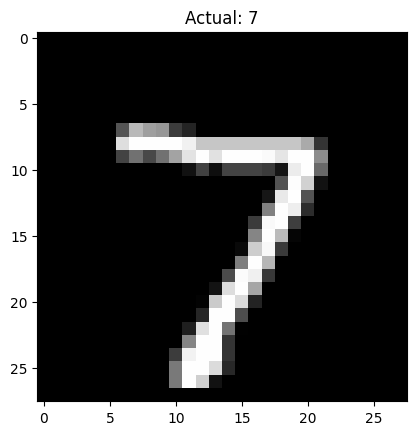

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Predicted: 7


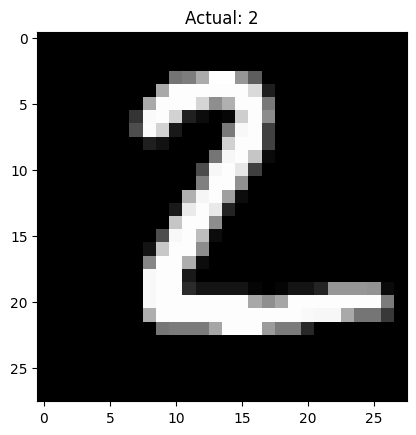

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted: 2


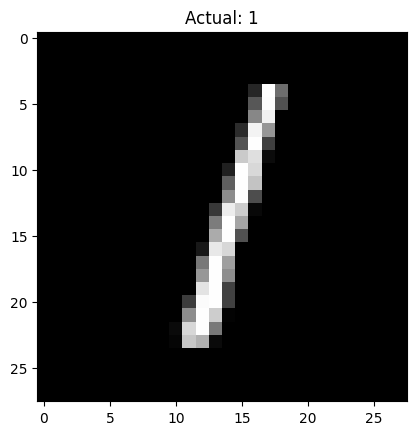

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted: 1


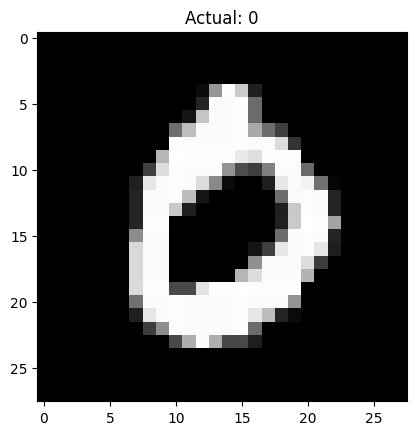

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted: 0


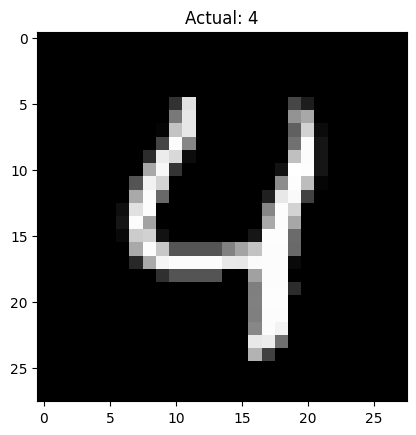

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted: 4


In [9]:
import numpy as np
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Actual: " + str(np.argmax(y_test[i])))
    plt.show()

    pred = model.predict(x_test[i].reshape(1,28,28,1))
    print("Predicted:", np.argmax(pred))

Test model on custom handwritten images

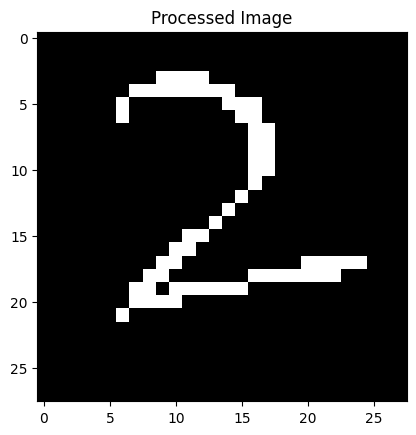

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted: 2


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Training image number 2.jpg', cv2.IMREAD_GRAYSCALE)

# Resize
img = cv2.resize(img, (28,28))

# Threshold (light cleanup)
_, img = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)

plt.imshow(img, cmap='gray')
plt.title("Processed Image")
plt.show()

# Normalize
img = img / 255.0
img = img.reshape(1,28,28,1)

pred = model.predict(img)
print("Predicted:", np.argmax(pred))

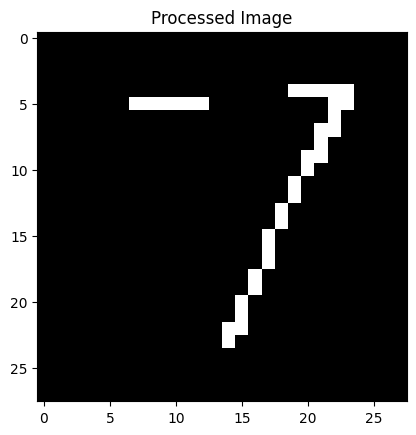

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted: 7


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Training image number 7.jpg', cv2.IMREAD_GRAYSCALE)

# Resize
img = cv2.resize(img, (28,28))

# Threshold (light cleanup)
_, img = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)

plt.imshow(img, cmap='gray')
plt.title("Processed Image")
plt.show()

# Normalize
img = img / 255.0
img = img.reshape(1,28,28,1)

pred = model.predict(img)
print("Predicted:", np.argmax(pred))

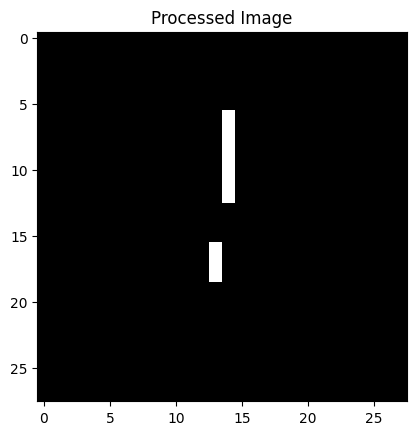

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted: 1


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Training image number 1.jpg', cv2.IMREAD_GRAYSCALE)

# Resize
img = cv2.resize(img, (28,28))

# Threshold (light cleanup)
_, img = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)

plt.imshow(img, cmap='gray')
plt.title("Processed Image")
plt.show()

# Normalize
img = img / 255.0
img = img.reshape(1,28,28,1)

pred = model.predict(img)
print("Predicted:", np.argmax(pred))